In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

BASE=Path().resolve().parent
PROC=BASE/"data"/"processed"
CHARTS=BASE/"reports"
CHARTS.mkdir(exist_ok=True)

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Paths
BASE   = Path(r"E:\bluestock_mf_capstone")
PROC   = BASE / "data" / "processed"
CHARTS = BASE / "reports"

# Reload all datasets
sip   = pd.read_csv(PROC / "clean_monthly_sip_inflows.csv")
aum   = pd.read_csv(PROC / "clean_aum_by_fund_house.csv")
nav   = pd.read_csv(PROC / "clean_nav_history.csv")
fm    = pd.read_csv(PROC / "clean_fund_master.csv")
tx    = pd.read_csv(PROC / "clean_investor_transactions.csv")
perf  = pd.read_csv(PROC / "clean_scheme_performance.csv")
folio = pd.read_csv(PROC / "clean_industry_folio_count.csv")

print("All datasets reloaded successfully")
print("sip:", sip.shape)
print("nav:", nav.shape)
print("tx:", tx.shape)
print("perf:", perf.shape)

All datasets reloaded successfully
sip: (48, 6)
nav: (46000, 4)
tx: (32778, 13)
perf: (40, 19)


## 1. SIP GROWTH OVER TIME

In [2]:
sip=pd.read_csv(PROC/"clean_monthly_sip_inflows.csv")
sip["month"]=pd.to_datetime(sip["month"])
sip=sip.sort_values("month")
print(sip.shape)
print(sip.head(3))

(48, 6)
       month  sip_inflow_crore  active_sip_accounts_crore  \
0 2022-01-01             11517                       4.91   
1 2022-02-01             11438                       4.93   
2 2022-03-01             12328                       5.09   

   new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct  
0                    9.1                4.80             NaN  
1                    8.2                4.85             NaN  
2                   10.5                5.01             NaN  


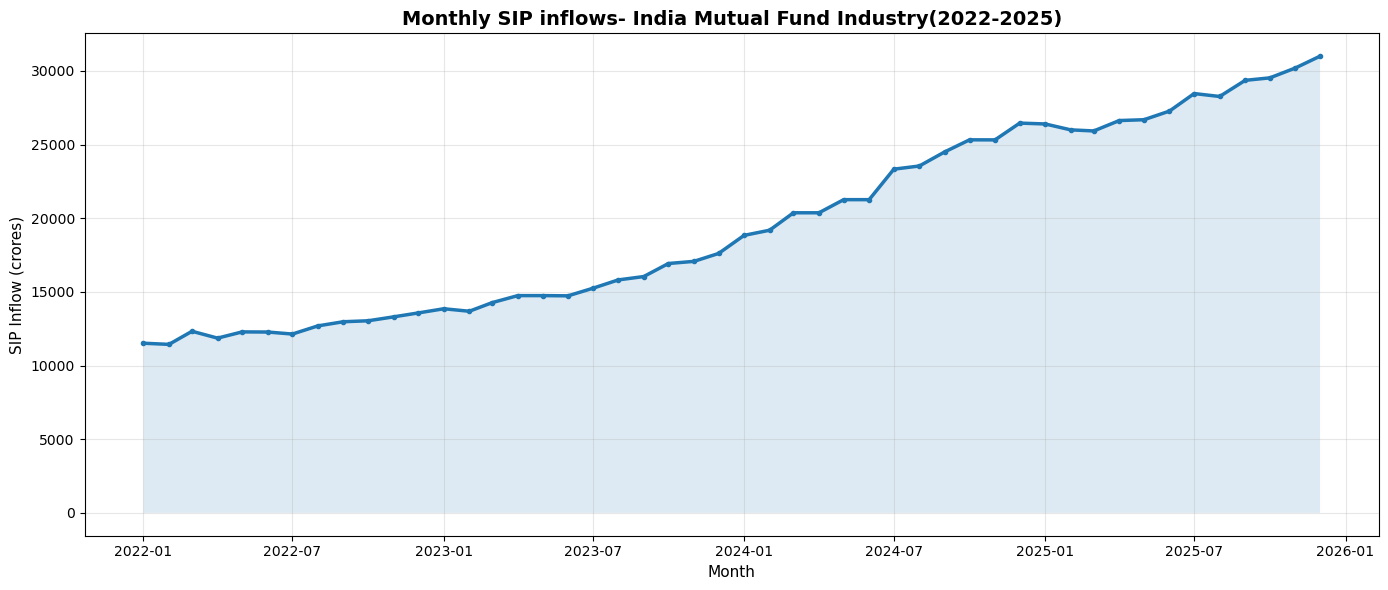

Chart 1 saved


In [3]:
fig,ax=plt.subplots(figsize=(14,6))
ax.plot(sip["month"],sip["sip_inflow_crore"],linewidth=2.5, marker="o",markersize=3)
#this will fill the area under the line
ax.fill_between(sip["month"],sip["sip_inflow_crore"],alpha=0.15)

ax.set_title("Monthly SIP inflows- India Mutual Fund Industry(2022-2025)",fontsize=14,fontweight="bold")
ax.set_xlabel("Month",fontsize=11)
ax.set_ylabel("SIP Inflow (crores)",fontsize=11)
ax.grid(True,alpha=0.3)

plt.tight_layout()
plt.savefig(CHARTS/"chart1_sip_inflow_trend.png")
plt.show()
print("Chart 1 saved")

## 2.AUM GROWTH BY FUND HOUSES

In [4]:
aum=pd.read_csv(PROC/"clean_aum_by_fund_house.csv")
aum["date"]=pd.to_datetime(aum["date"])
aum["year"]=aum["date"].dt.year
print(aum["fund_house"].unique())
print(aum.shape)

['SBI Mutual Fund' 'ICICI Prudential MF' 'HDFC Mutual Fund'
 'Nippon India MF' 'Kotak Mahindra MF' 'Aditya Birla Sun Life MF'
 'Axis Mutual Fund' 'UTI Mutual Fund' 'Mirae Asset MF' 'DSP Mutual Fund']
(90, 6)


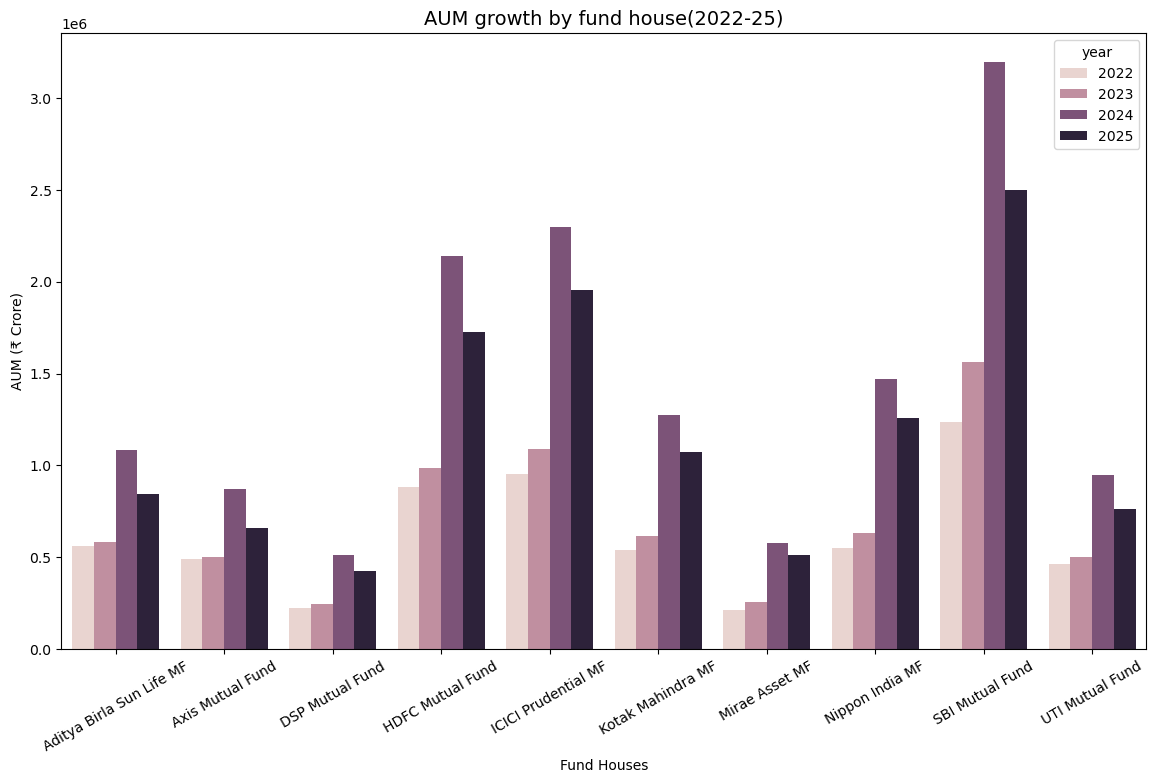

In [5]:
aum_yearly=aum.groupby(["fund_house","year"])["aum_crore"].sum().reset_index()
fig, ax= plt.subplots(figsize=(14,8))
sns.barplot(data=aum_yearly,x="fund_house",y="aum_crore",hue="year")
plt.title("AUM growth by fund house(2022-25)",fontsize=14)
plt.xlabel("Fund Houses")
plt.ylabel("AUM (₹ Crore)")
plt.xticks(rotation=30)
plt.savefig(CHARTS/"chart2_aum_growth.png")
plt.show()

## 3. NAV Trend for top 5 Funds

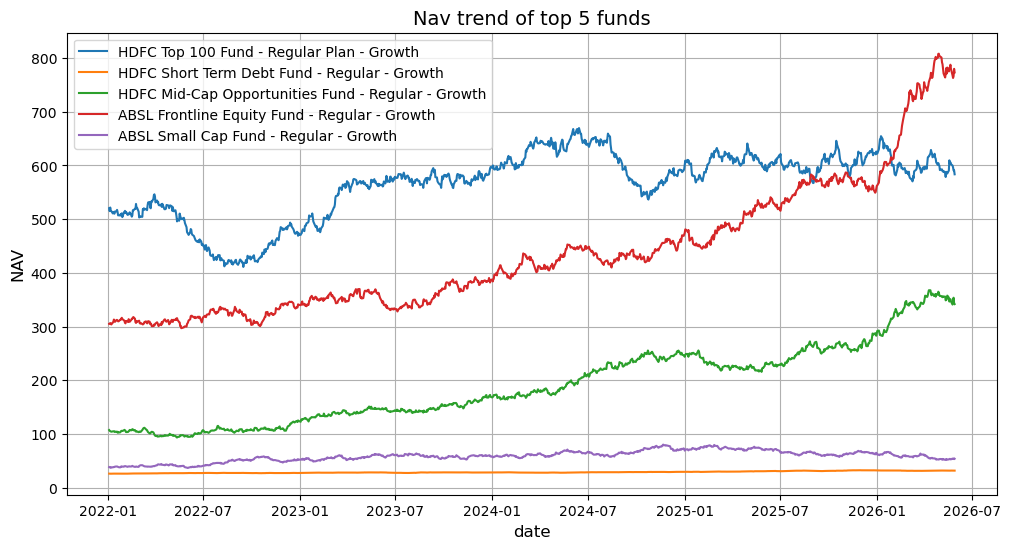

In [6]:
nav=pd.read_csv(PROC/"clean_nav_history.csv")
nav["date"]=pd.to_datetime(nav["date"])

fm=pd.read_csv(PROC/"clean_fund_master.csv")
scheme_names = fm.set_index("amfi_code")["scheme_name"].to_dict()

top5_code=nav["amfi_code"].unique()[:5]

plt.figure(figsize=(12,6))
for code in top5_code:
    nav5=nav[nav["amfi_code"]==code]
    plt.plot(nav5["date"],nav5["nav"],label=scheme_names[code])

plt.title("Nav trend of top 5 funds",fontsize=14)
plt.xlabel("date",fontsize=12)
plt.ylabel("NAV",fontsize=12)
plt.grid(True)
plt.legend()
plt.savefig(CHARTS/"chart3_nav_trends.png")

plt.show()

## 4. Correlation Heatmap

In [7]:
nav_pivot=nav.pivot_table(
    index="date",
    columns="amfi_code",
    values="nav"
)

print("Shape:", nav_pivot.shape)
print("First 2 rows:")
print(nav_pivot.head(2))

Shape: (1150, 40)
First 2 rows:
amfi_code     100016   100025    100033    101206   101207    101208   102885  \
date                                                                            
2022-01-03  520.4608  26.3169  107.3758  305.0996  38.5736  310.7415  89.8728   
2022-01-04  515.0971  26.2234  105.9447  305.4514  38.1545  310.6977  90.8724   

amfi_code     102886    102887   118632  ...   120843     120844    125497  \
date                                     ...                                 
2022-01-03  119.2905  191.0721  42.8339  ...  49.9131  3180.6318  560.1443   
2022-01-04  120.6402  189.0737  42.8033  ...  50.8195  3181.4042  560.7052   

amfi_code     125498   148567   148568   148569    149322   149323   149324  
date                                                                         
2022-01-03  117.5969  70.2514  84.0757  28.8620  348.7159  78.4622  81.6814  
2022-01-04  117.0077  71.6085  85.4096  29.1038  345.7198  78.5000  80.8239  

[2 rows x 40 colu

In [8]:
# We calculate daily returns instead of using raw NAV
# Why? Because all NAVs trend upward over time
# That would make every fund look correlated
# Returns show the TRUE relationship

# pct_change() = (today - yesterday) / yesterday
# Example: NAV went from 100 to 102 → return = 2%

returns_pivot = nav_pivot.pct_change().dropna()
# dropna() removes the first row which has no previous day

print("Returns shape:", returns_pivot.shape)
print("Sample returns (first 2 rows):")
print(returns_pivot.head(2).round(4))

Returns shape: (1149, 40)
Sample returns (first 2 rows):
amfi_code   100016  100025  100033  101206  101207  101208  102885  102886  \
date                                                                         
2022-01-04 -0.0103 -0.0036 -0.0133  0.0012 -0.0109 -0.0001  0.0111  0.0113   
2022-01-05  0.0129 -0.0000 -0.0044  0.0039  0.0006  0.0004 -0.0079  0.0068   

amfi_code   102887  118632  ...  120843  120844  125497  125498  148567  \
date                        ...                                           
2022-01-04 -0.0105 -0.0007  ...  0.0182  0.0002  0.0010 -0.0050  0.0193   
2022-01-05 -0.0053  0.0059  ... -0.0123  0.0005  0.0043 -0.0052 -0.0039   

amfi_code   148568  148569  149322  149323  149324  
date                                                
2022-01-04  0.0159  0.0084 -0.0086  0.0005 -0.0105  
2022-01-05 -0.0077  0.0153 -0.0065  0.0087 -0.0026  

[2 rows x 40 columns]


In [9]:
# Right now columns are amfi codes like 119551, 120503
# We want readable names like "SBI Bluechip"

# Create a dictionary: {amfi_code: short_name}
code_to_name = fm.set_index("amfi_code")["scheme_name"].str[:20].to_dict()
# str[:20] means take only first 20 characters of the name
# because full names are too long for the chart

# Rename the columns
returns_pivot.columns = [
    code_to_name.get(c, c) 
    for c in returns_pivot.columns
]
# .get(c, c) means: if code found in dictionary use name, else keep code

# Now calculate correlation
# corr() compares every column against every other column
# Result is a square table — 40 funds x 40 funds
corr = returns_pivot.corr()

print("Correlation matrix size:", corr.shape)
print("Sample — first 3 funds vs first 3 funds:")
print(corr.iloc[:3, :3].round(2))

Correlation matrix size: (40, 40)
Sample — first 3 funds vs first 3 funds:
                      HDFC Top 100 Fund -   HDFC Short Term Debt  \
HDFC Top 100 Fund -                   1.00                  0.05   
HDFC Short Term Debt                  0.05                  1.00   
HDFC Mid-Cap Opportu                 -0.00                  0.00   

                      HDFC Mid-Cap Opportu  
HDFC Top 100 Fund -                   -0.0  
HDFC Short Term Debt                   0.0  
HDFC Mid-Cap Opportu                   1.0  


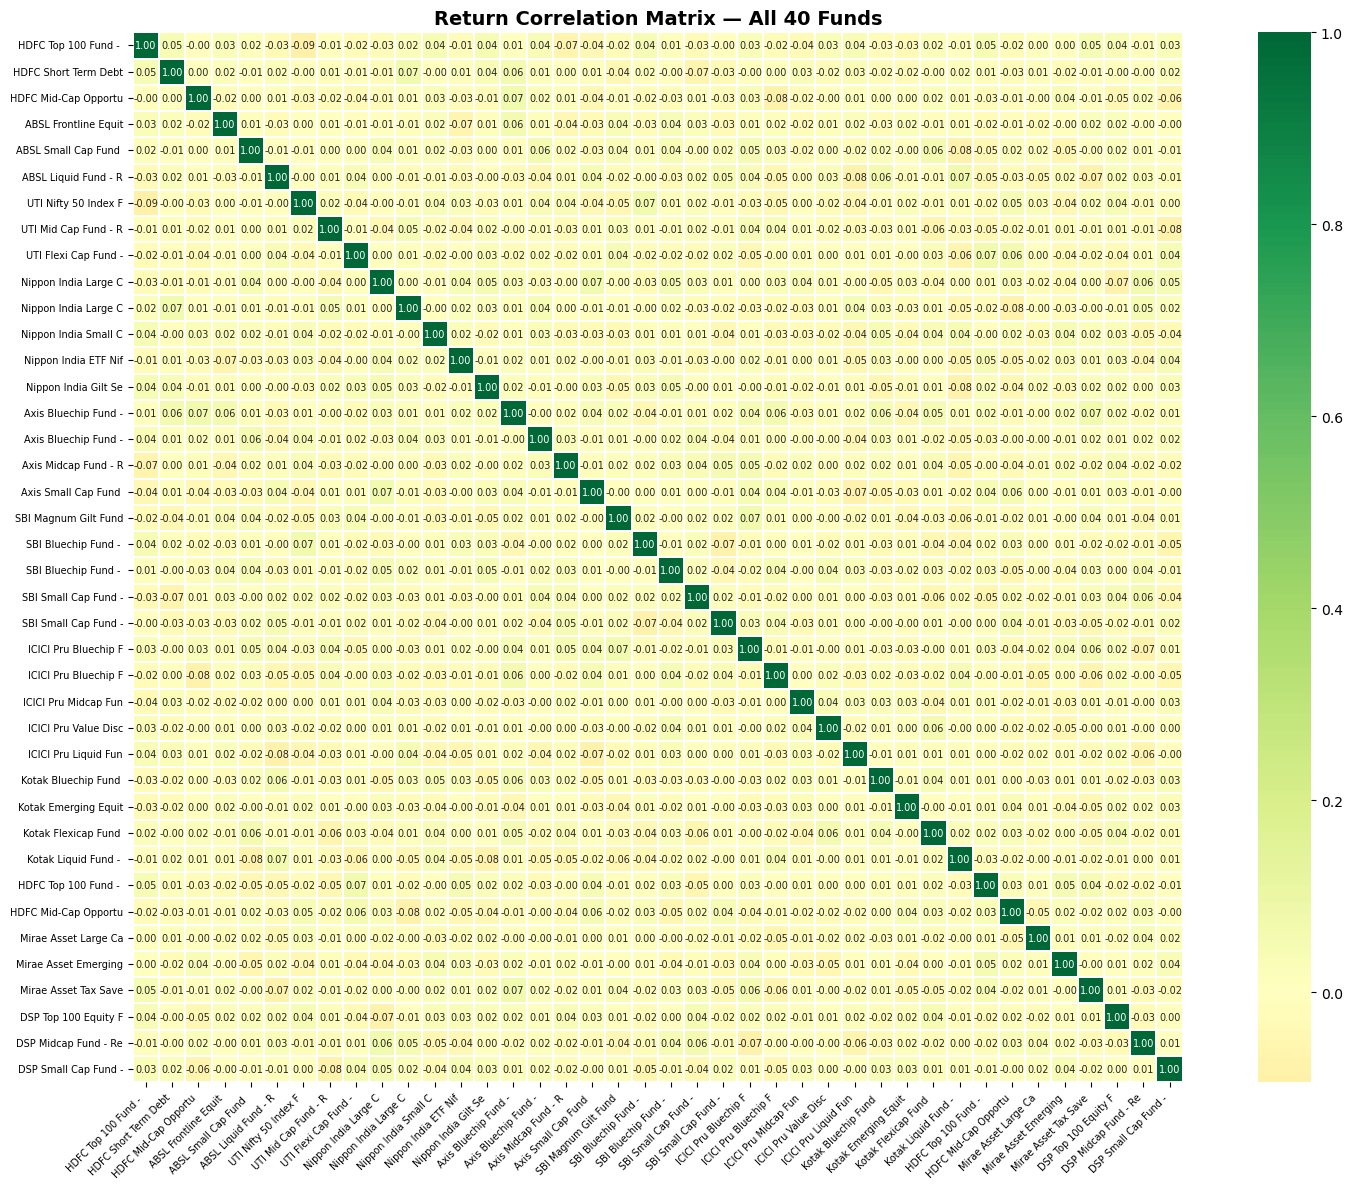

Chart 4 saved


In [10]:
# Create a large figure — 40x40 grid needs space
fig, ax = plt.subplots(figsize=(16, 12))

# Draw heatmap
# annot=True means show the number inside each box
# fmt=".2f" means show 2 decimal places like 0.85
# cmap="RdYlGn" means Red=low correlation, Green=high correlation
# center=0 means 0 correlation gets yellow (middle color)

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    square=True,
    linewidths=0.3,
    annot_kws={"size": 7},
    ax=ax
)

# Title and labels
ax.set_title("Return Correlation Matrix — All 40 Funds",
             fontsize=14, fontweight="bold")

# Rotate x-axis labels so they don't overlap
ax.set_xticklabels(
    ax.get_xticklabels(), 
    rotation=45,    # tilt 45 degrees
    ha="right",     # align to right
    fontsize=7
)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=7)

plt.tight_layout()  # automatically adjust spacing
plt.savefig(CHARTS / "chart4_correlation_heatmap.png", dpi=150)
plt.show()
print("Chart 4 saved")

## insights
#Most Indian mutual funds in this dataset move together. This suggests they are all heavily invested in the same large-cap stocks 
#like Reliance, TCS, HDFC. 
#A retail investor buying 3-4 different funds may think they are diversified but they are actually taking similar risk.

## 5.Investor Age Group Distribution

In [11]:
tx=pd.read_csv(PROC/"clean_investor_transactions.csv")
age_counts=tx["age_group"].value_counts()
print(age_counts)

age_group
26-35    13463
36-45     8146
18-25     4916
46-55     3779
56+       2474
Name: count, dtype: int64


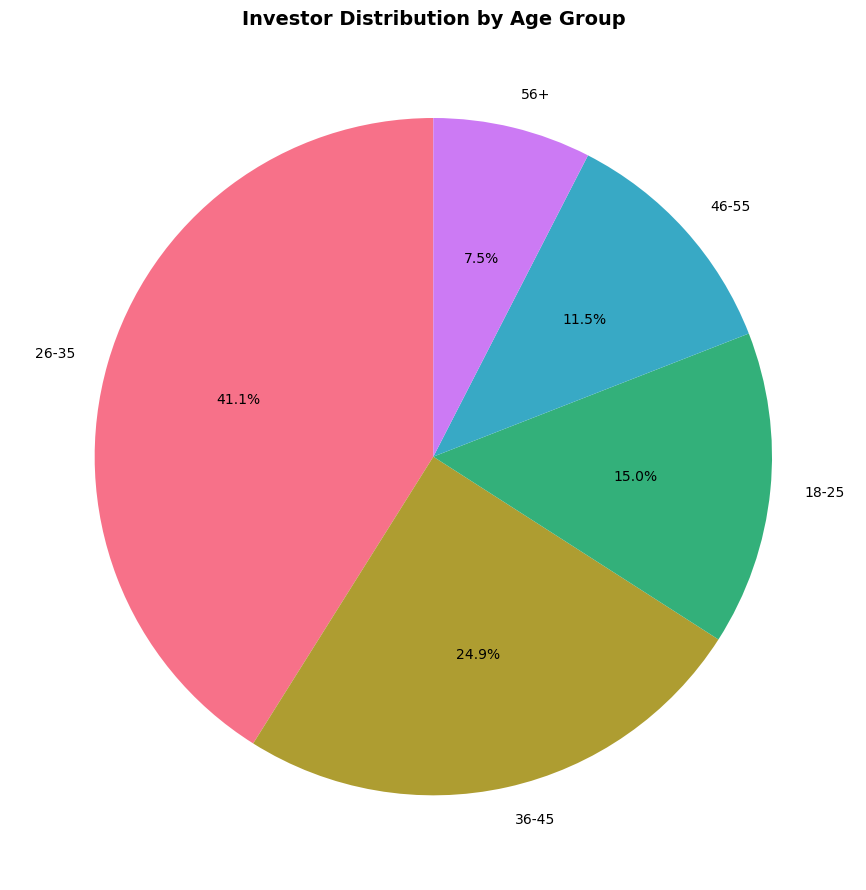

Chart 5 saved


In [12]:
fig, ax= plt.subplots(figsize=(9,9))

ax.pie(age_counts.values,labels=age_counts.index,autopct="%1.1f%%",startangle=90,colors=sns.color_palette("husl", len(age_counts)))
ax.set_title("Investor Distribution by Age Group", fontsize=14,fontweight="bold")
plt.tight_layout()
plt.savefig(CHARTS / "chart5_age_distribution.png", dpi=150)
plt.show()
print("Chart 5 saved")

#Bluestock should focus marketing efforts on the 26-35 age group as they represent the largest investor segment. 
#Additionally, the 18-25 segment represents a growth opportunity as young earners are just beginning their investment journey.

## 6. SIP Amount by State

In [13]:
# Filter only SIP transactions
sip_tx = tx[tx["transaction_type"] == "Sip"]
# This keeps only rows where transaction type is SIP
# We exclude Lumpsum and Redemption

# Calculate total SIP amount per state
state_sip = sip_tx.groupby("state")["amount_inr"].sum()
# groupby("state") = group all rows by state
# ["amount_inr"].sum() = add up all amounts in each group

# Sort from highest to lowest
state_sip = state_sip.sort_values(ascending=True)
# ascending=True because horizontal bar charts
# look better with highest value at top

print(state_sip)

state
Maharashtra       16445629
Rajasthan         16544233
Delhi             17113608
West Bengal       17495769
Uttar Pradesh     17534858
Karnataka         17696903
Haryana           18176696
Gujarat           18378904
Tamil Nadu        18404368
Telangana         18620216
Punjab            20140064
Madhya Pradesh    20682243
Name: amount_inr, dtype: int64


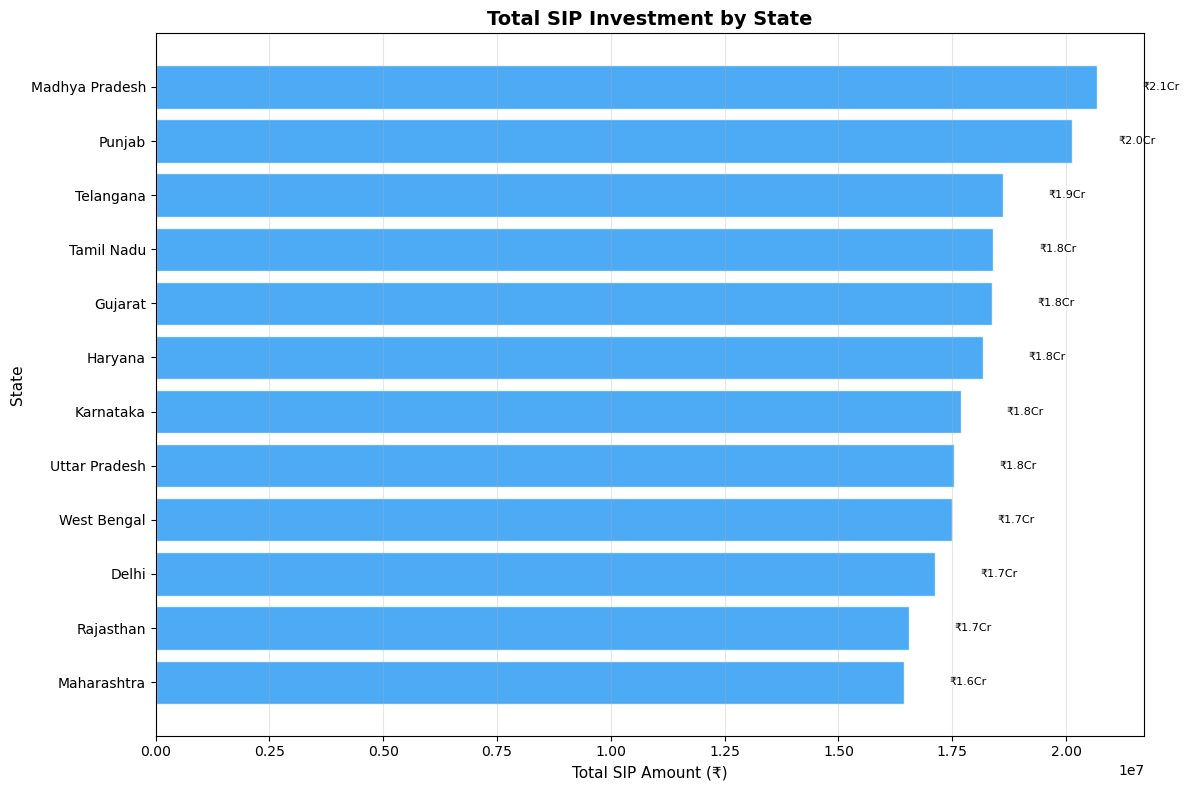

Chart 6 saved


In [14]:
fig, ax = plt.subplots(figsize=(12, 8))

# Draw horizontal bar chart
# state_sip.values = the amounts
# state_sip.index = the state names
ax.barh(
    state_sip.index,
    state_sip.values,
    color="#2196F3",
    alpha=0.8,
    edgecolor="white"
)

# Add value labels at end of each bar
for i, (state, value) in enumerate(state_sip.items()):
    ax.text(
        value + 1000000,   # position slightly right of bar end
        i,                  # vertical position
        f"₹{value/1e7:.1f}Cr",  # format as crore
        va="center",
        fontsize=8
    )

ax.set_title("Total SIP Investment by State",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Total SIP Amount (₹)", fontsize=11)
ax.set_ylabel("State", fontsize=11)
ax.grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.savefig(CHARTS / "chart6_sip_by_state.png", dpi=150)
plt.show()
print("Chart 6 saved")

In [15]:
#MP, Punjab, and Telangana are the top SIP contributing states. 
#Bluestock should prioritize these markets for premium product offerings and relationship managers. States at the bottom of the chart represent untapped markets where financial literacy campaigns could unlock new investors.

## 7. Transacton Type Split

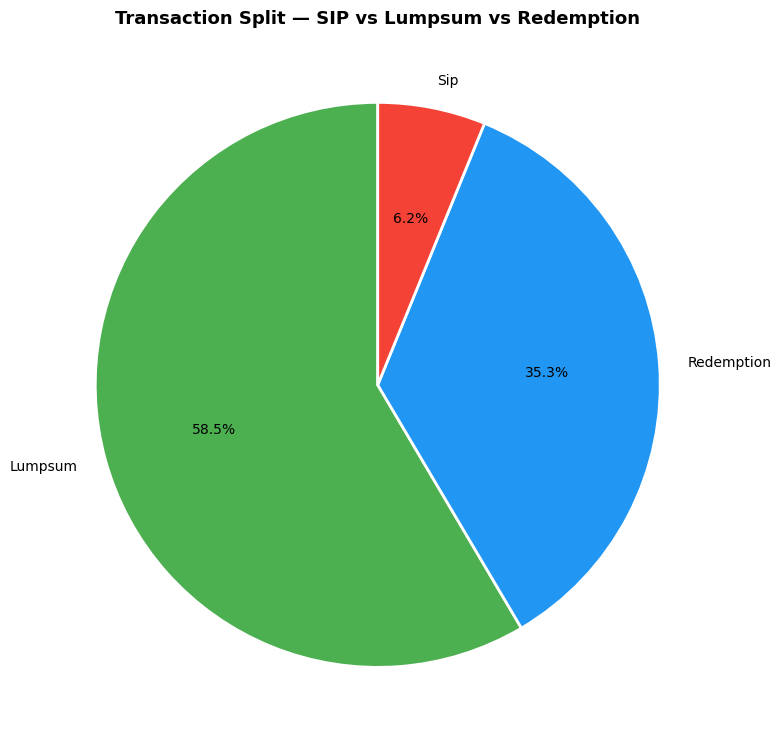

Chart 7 saved


In [16]:
# Count and sum by transaction type
tx_split = tx.groupby("transaction_type")["amount_inr"].sum().reset_index()
tx_split.columns = ["type", "total_amount"]
tx_split = tx_split.sort_values("total_amount", ascending=False)

fig, ax = plt.subplots(figsize=(8, 8))

colors = ["#4CAF50", "#2196F3", "#F44336"]
# Green=SIP(good), Blue=Lumpsum(neutral), Red=Redemption(money leaving)

ax.pie(
    tx_split["total_amount"],
    labels=tx_split["type"],
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)

ax.set_title("Transaction Split — SIP vs Lumpsum vs Redemption",
             fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig(CHARTS / "chart7_transaction_split.png", dpi=150)
plt.show()
print("Chart 7 saved")

## 8.T30 vs B30 Investment

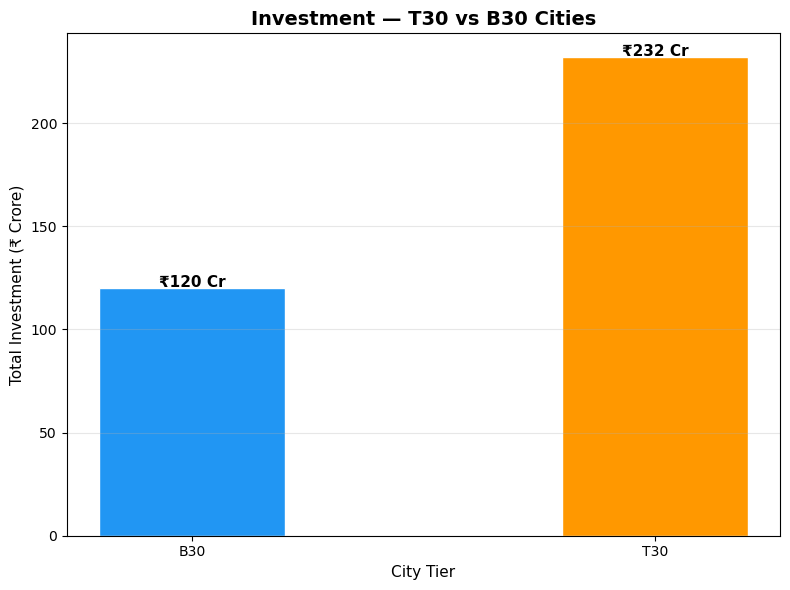

Chart 8 saved


In [17]:
# Group by city tier
tier_data = tx.groupby("city_tier")["amount_inr"].sum().reset_index()

fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.bar(
    tier_data["city_tier"],
    tier_data["amount_inr"] / 1e7,  # convert to crore
    color=["#2196F3", "#FF9800"],
    width=0.4,
    edgecolor="white"
)

# Add value on top of each bar
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f"₹{height:.0f} Cr",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

ax.set_title("Investment — T30 vs B30 Cities",
             fontsize=14, fontweight="bold")
ax.set_xlabel("City Tier", fontsize=11)
ax.set_ylabel("Total Investment (₹ Crore)", fontsize=11)
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(CHARTS / "chart8_t30_vs_b30.png", dpi=150)
plt.show()
print("Chart 8 saved")

## 9. Top 10 Funds by Sharpe Ratio

In [18]:
#What is Sharpe Ratio in simple words?
#Imagine two funds:

#Fund A gave 15% return but was very volatile — up 30% one month, down 20% next
#Fund B gave 13% return but was smooth and steady every month

#Fund B is actually better for most investors. Sharpe Ratio measures this — return per unit of risk. Higher Sharpe = better quality returns.

In [21]:
perf = pd.read_csv(PROC / "clean_scheme_performance.csv")
print(perf.columns.tolist())

['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']


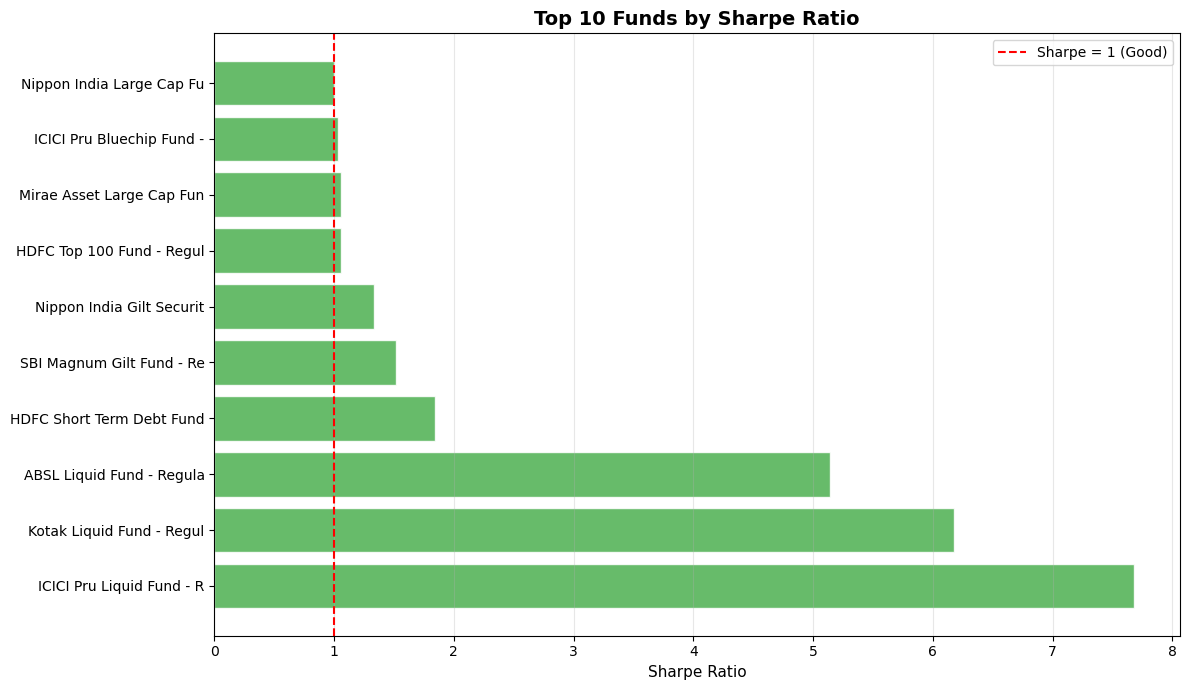

Chart 9 saved


In [22]:
# perf already has scheme_name — no merge needed
top_sharpe = perf.nlargest(10, "sharpe_ratio")

# Shorten names for chart
top_sharpe["short_name"] = top_sharpe["scheme_name"].str[:25]

fig, ax = plt.subplots(figsize=(12, 7))

ax.barh(
    top_sharpe["short_name"],
    top_sharpe["sharpe_ratio"],
    color="#4CAF50",
    alpha=0.85,
    edgecolor="white"
)

# Red line at Sharpe = 1 means "good" threshold
ax.axvline(x=1, color="red", linestyle="--",
           linewidth=1.5, label="Sharpe = 1 (Good)")

ax.set_title("Top 10 Funds by Sharpe Ratio",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Sharpe Ratio", fontsize=11)
ax.legend()
ax.grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.savefig(CHARTS / "chart9_top_sharpe.png", dpi=150)
plt.show()
print("Chart 9 saved")

In [ ]:
# Check what columns exist in both dataframes
print("perf columns:", perf.columns.tolist())
print("fm columns:", fm.columns.tolist())

## 10. Folio Count Growth

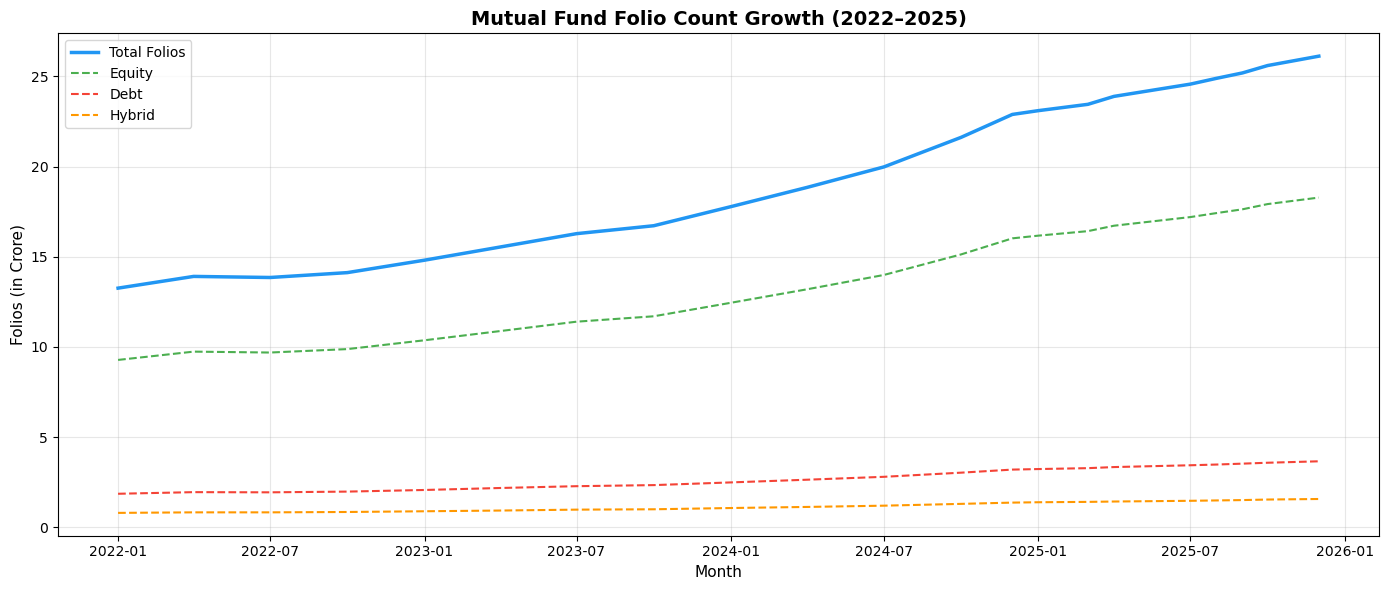

In [25]:
# Column is "month" not "date"
folio["month"] = pd.to_datetime(folio["month"])
folio = folio.sort_values("month")

fig, ax = plt.subplots(figsize=(14, 6))

# Plot total folios as main line
ax.plot(folio["month"], folio["total_folios_crore"],
        color="#2196F3", linewidth=2.5, label="Total Folios")

# Plot breakdown lines
ax.plot(folio["month"], folio["equity_folios_crore"],
        color="#4CAF50", linewidth=1.5, linestyle="--", label="Equity")

ax.plot(folio["month"], folio["debt_folios_crore"],
        color="#F44336", linewidth=1.5, linestyle="--", label="Debt")

ax.plot(folio["month"], folio["hybrid_folios_crore"],
        color="#FF9800", linewidth=1.5, linestyle="--", label="Hybrid")

ax.set_title("Mutual Fund Folio Count Growth (2022–2025)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Month", fontsize=11)
ax.set_ylabel("Folios (in Crore)", fontsize=11)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(CHARTS / "chart10_folio_growth.png", dpi=150)
plt.show()
#print("Chart 10 saved")

In [ ]:


# Business insight for your report: Total folios grew from 13.26 crore in January 2022 to 26.12 crore by end of 2025 — nearly doubling in 4 years. 
# Equity folios dominate, confirming that Indian retail investors are increasingly comfortable with equity risk. This aligns with the SIP growth story 
# from Chart 1 — more investors, more monthly contributions.


## 11. Category Distribution

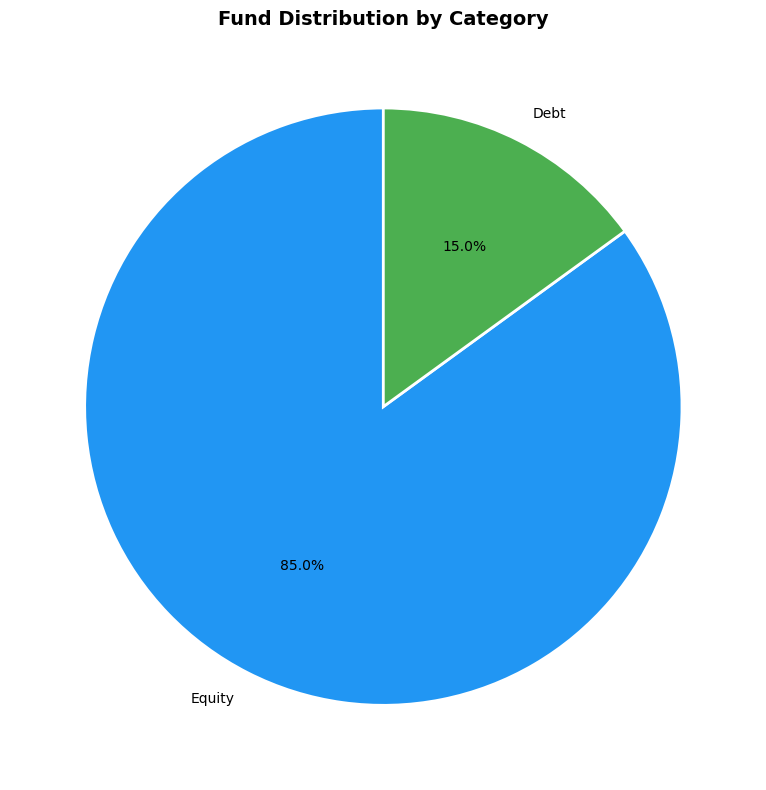

Chart 11 saved


In [26]:
category_counts = fm["category"].value_counts()

fig, ax = plt.subplots(figsize=(8, 8))

ax.pie(
    category_counts.values,
    labels=category_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#2196F3", "#4CAF50", "#FF9800", "#E91E63"],
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)

ax.set_title("Fund Distribution by Category",
             fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig(CHARTS / "chart11_category_distribution.png", dpi=150)
plt.show()
print("Chart 11 saved")

## 12. Top 10 fund by 3-year Returns

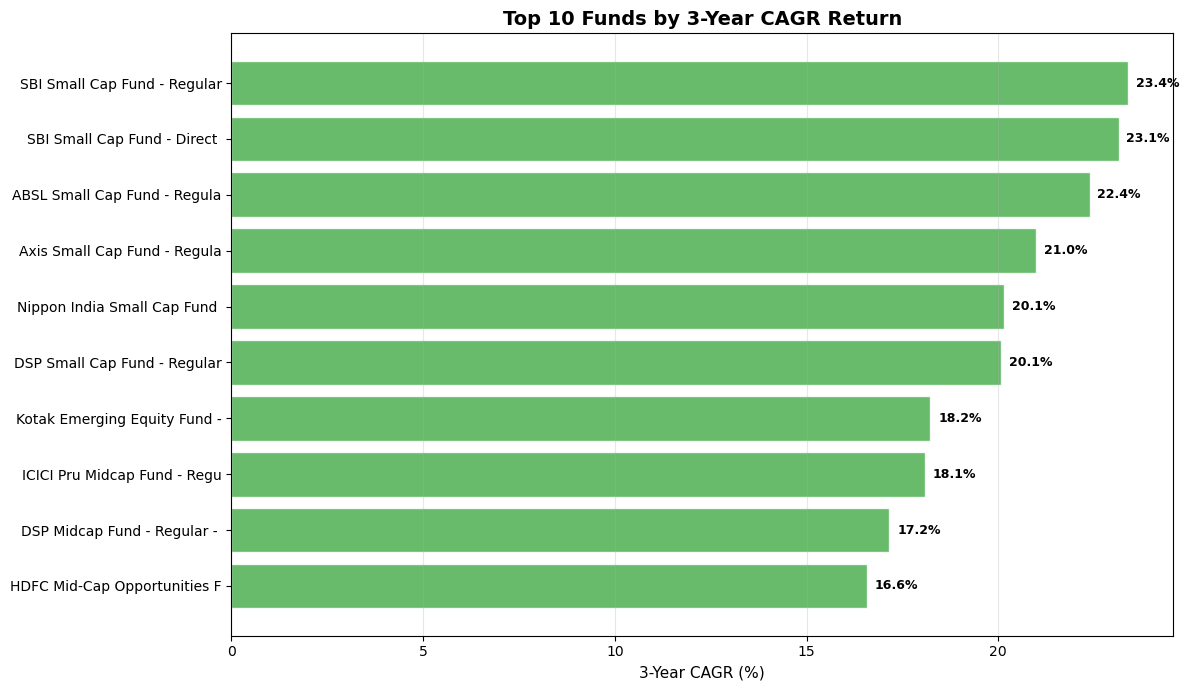

Chart 12 saved


In [27]:
top_returns = perf.nlargest(10, "return_3yr_pct")[
    ["scheme_name", "return_3yr_pct", "category"]
]
top_returns["short_name"] = top_returns["scheme_name"].str[:28]
top_returns = top_returns.sort_values("return_3yr_pct", ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(
    top_returns["short_name"],
    top_returns["return_3yr_pct"],
    color="#4CAF50",
    alpha=0.85,
    edgecolor="white"
)

# Add value labels at end of each bar
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}%",
        va="center",
        fontsize=9,
        fontweight="bold"
    )

ax.set_title("Top 10 Funds by 3-Year CAGR Return",
             fontsize=14, fontweight="bold")
ax.set_xlabel("3-Year CAGR (%)", fontsize=11)
ax.grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.savefig(CHARTS / "chart12_top_returns.png", dpi=150)
plt.show()
print("Chart 12 saved")

In [28]:
# Top performing funds over 3 years are all Equity funds with CAGR reaching 23.4%. This confirms the fundamental principle of investing — equity 
# gives the highest long-term returns but comes with higher risk. Debt funds are safer but will never appear in this
# top 10 list

## 13. Max Drawdown Comparison

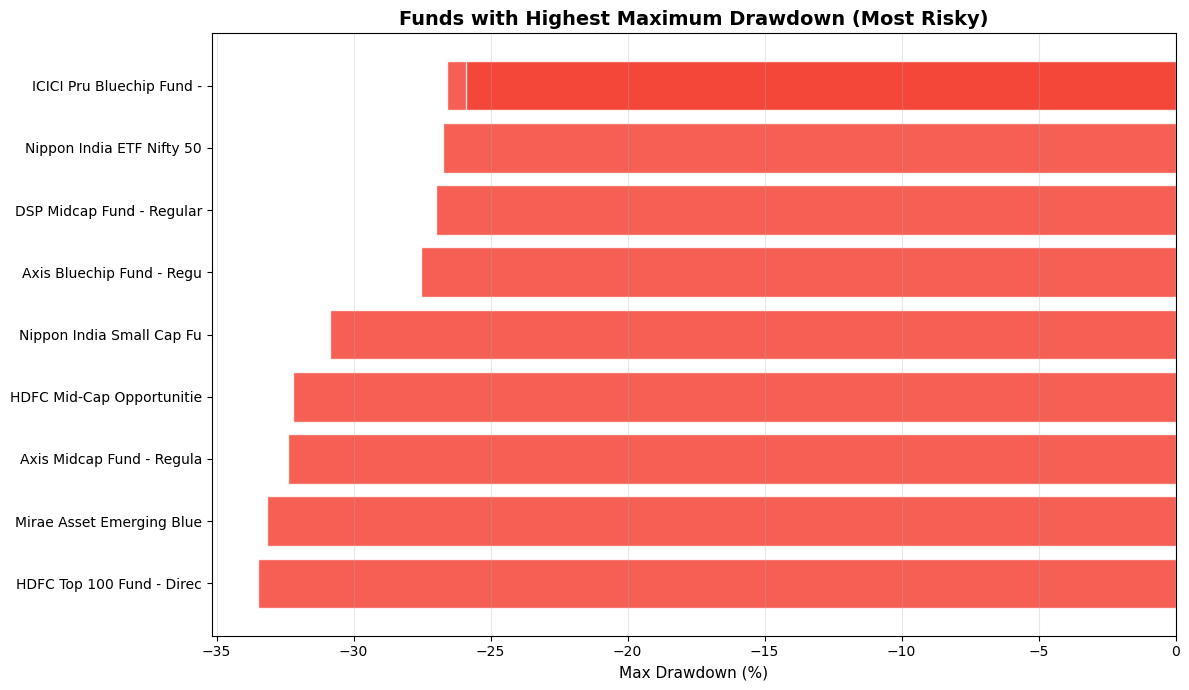

Chart 13 saved


In [29]:
# Max drawdown = worst fall from peak
# More negative = more risky fund
worst_dd = perf.nsmallest(10, "max_drawdown_pct")[
    ["scheme_name", "max_drawdown_pct"]
]
worst_dd["short_name"] = worst_dd["scheme_name"].str[:25]
worst_dd = worst_dd.sort_values("max_drawdown_pct", ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))

ax.barh(
    worst_dd["short_name"],
    worst_dd["max_drawdown_pct"],
    color="#F44336",
    alpha=0.85,
    edgecolor="white"
)

ax.set_title("Funds with Highest Maximum Drawdown (Most Risky)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Max Drawdown (%)", fontsize=11)
ax.grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.savefig(CHARTS / "chart13_max_drawdown.png", dpi=150)
plt.show()
print("Chart 13 saved")

## 14. Monthly SIP Accounts Growth

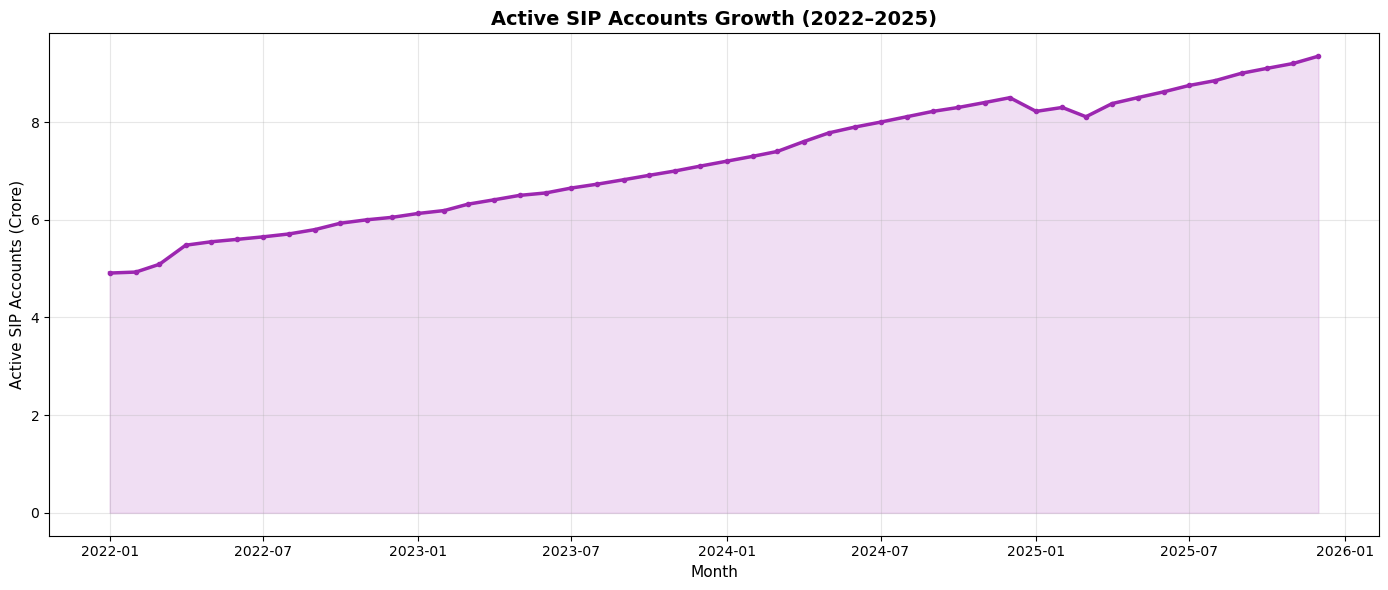

Chart 14 saved


In [30]:
sip["month"] = pd.to_datetime(sip["month"])
sip = sip.sort_values("month")

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    sip["month"],
    sip["active_sip_accounts_crore"],
    color="#9C27B0",
    linewidth=2.5,
    marker="o",
    markersize=3
)

ax.fill_between(
    sip["month"],
    sip["active_sip_accounts_crore"],
    alpha=0.15,
    color="#9C27B0"
)

ax.set_title("Active SIP Accounts Growth (2022–2025)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Month", fontsize=11)
ax.set_ylabel("Active SIP Accounts (Crore)", fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(CHARTS / "chart14_sip_accounts.png", dpi=150)
plt.show()
print("Chart 14 saved")

## 15. Risk vs Return Scatter plot 

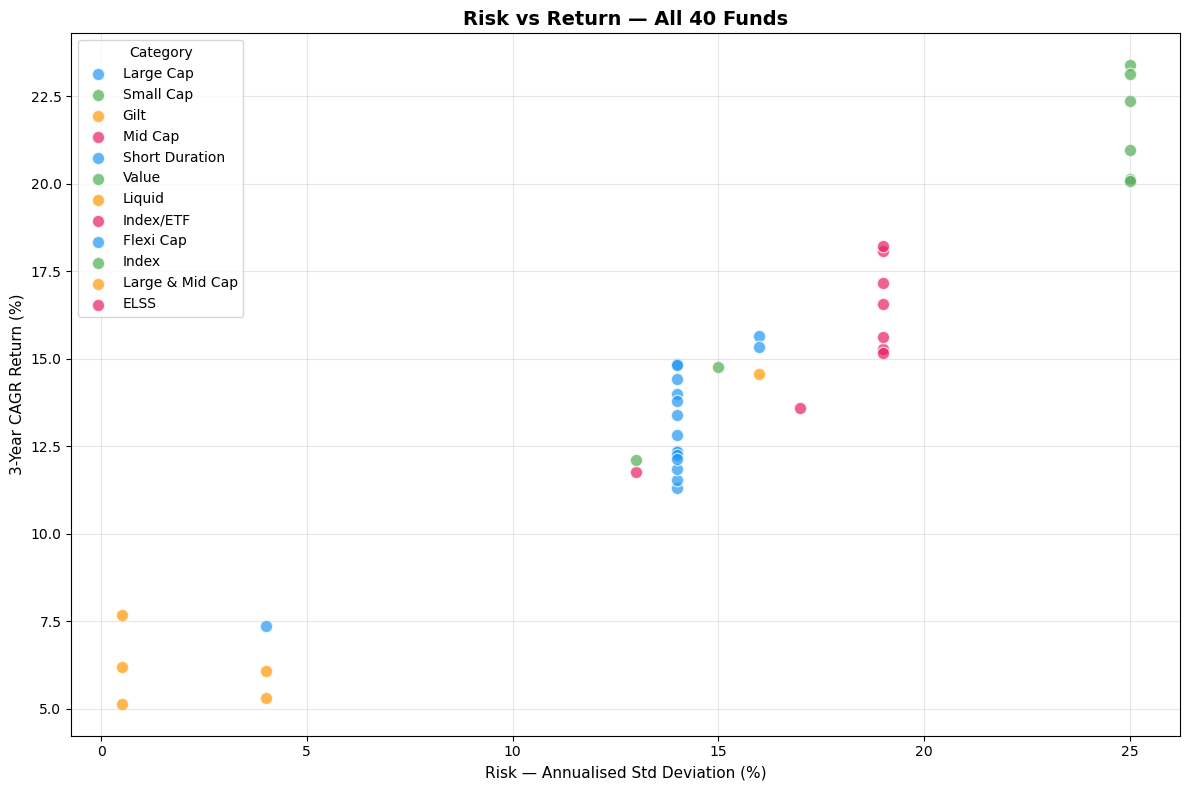

Chart 15 saved


In [31]:
# This is the most important chart in fund analysis
# X axis = risk (standard deviation)
# Y axis = return (3 year CAGR)
# Each dot = one fund
# Good funds = high return, low risk = top left corner

fig, ax = plt.subplots(figsize=(12, 8))

# Color dots by category
categories = perf["category"].unique()
colors = ["#2196F3", "#4CAF50", "#FF9800", "#E91E63"]

for i, cat in enumerate(categories):
    cat_data = perf[perf["category"] == cat]
    ax.scatter(
        cat_data["std_dev_ann_pct"],
        cat_data["return_3yr_pct"],
        label=cat,
        color=colors[i % len(colors)],
        alpha=0.7,
        s=80,
        edgecolors="white"
    )

ax.set_title("Risk vs Return — All 40 Funds",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Risk — Annualised Std Deviation (%)", fontsize=11)
ax.set_ylabel("3-Year CAGR Return (%)", fontsize=11)
ax.legend(title="Category")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(CHARTS / "chart15_risk_vs_return.png", dpi=150)
plt.show()
print("Chart 15 saved")